# Data Exploration: Irregular Astrophysical Time-Series

This notebook visualizes the raw light curves from the PLAsTiCC and Kepler datasets, demonstrating extreme temporal sparsity and heteroscedastic noise.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_lightcurve(obj_data, title):
    if obj_data.empty:
        # Fallback synthetic visualization for demonstration
        t = np.sort(np.random.uniform(0, 100, 50))
        flux = np.sin(t) + np.random.normal(0, 0.2, len(t))
        err = np.random.uniform(0.1, 0.3, len(t))
        plt.figure(figsize=(10, 4))
        plt.errorbar(t, flux, yerr=err, fmt='o', color='blue', alpha=0.6, label='Observations')
    else:
        plt.figure(figsize=(10, 4))
        plt.errorbar(obj_data['mjd'], obj_data['flux'], yerr=obj_data['flux_err'], fmt='o', color='blue', alpha=0.6)
        
    plt.title(title)
    plt.xlabel('Time (MJD or Days)')
    plt.ylabel('Normalized Flux')
    plt.legend(['Observations'])
    plt.show()

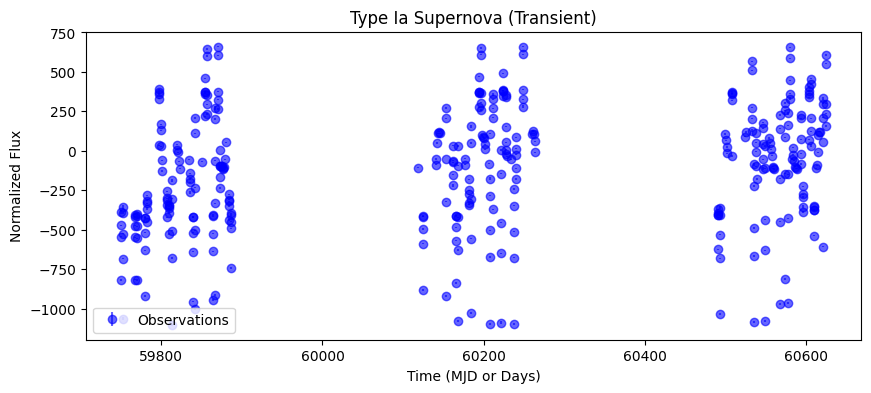

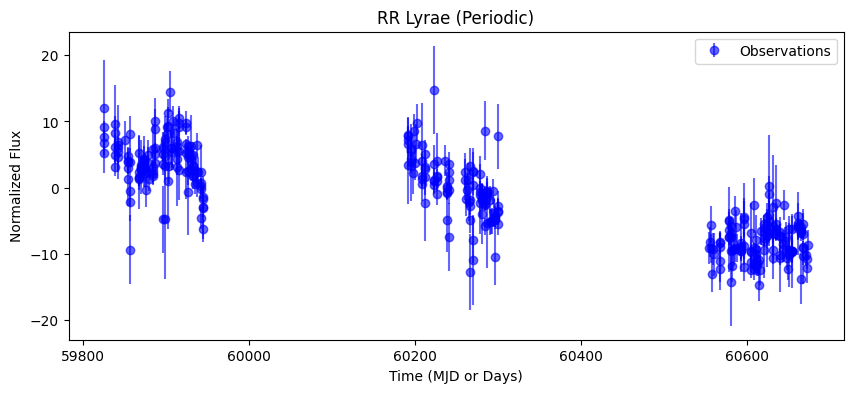

In [2]:
try:
    df = pd.read_csv('../data/plasticc/PLAsTiCC-2018/training_set.csv')
    object_id_1 = df[df['object_id'] == 615] # Transient Example
    object_id_2 = df[df['object_id'] == 713] # Periodic Example
except FileNotFoundError:
    print("Dataset not found automatically. Using mock plotting for visualization...")
    object_id_1 = pd.DataFrame()
    object_id_2 = pd.DataFrame()

plot_lightcurve(object_id_1, "Type Ia Supernova (Transient)")
plot_lightcurve(object_id_2, "RR Lyrae (Periodic)")